## Phase 2: Training a Model
In this phase, we will use the data we perpared in phase 1 to:

- create a train, test and validation split,
- handle the observed imbalance in class distrubution,
- choose and train a model that fits the task,
- evaluate the model,
- tune the model.

#### Create a train, test and validation split
We load the in phase 1 created .csv file with the preprocessed/cleaned data. And create a train, test and vaildation split. As stated in phase 1, we will try to predict the department as well as the priority of a given ticket. First, we will focus on just predicting the department alone and later on we will tackle multiple outputs.

In [1]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split

filepath = "../data/dataset_en_clean.csv"
df = pd.read_csv(filepath) # Load the in phase 1 prepared data

X = df["clean_text"] 
y = df["queue"]

# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=15, stratify=y) 

# Create train-validation split
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.20, random_state=15, stratify=y_train)

#### Verctorize the data
We measure and evaluate how important a word is in a ticket 'body' within the 'X_train', 'X_test' and 'X_validation' set respectively, by calculating TF-IDF.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

# Apply vectorization
X_train_vec = vectorizer.fit_transform(X_train) 
X_test_vec = vectorizer.transform(X_test)
X_validation_vec = vectorizer.transform(X_validation)

#### Handle the class imbalance
When looking at the number at data points per label (department), we still see the in phase 1 observed imbalance in terms of class distribution. 

In [3]:
print(y_train.value_counts())

queue
technical support                  3221
product support                    2089
customer service                   1638
it support                         1321
billing and payments               1085
returns and exchanges               557
service outages and maintenance     451
sales and pre-sales                 349
human resources                     237
general inquiry                     161
Name: count, dtype: int64


To handle this imbalance, we will apply oversampling, where random samples are used multiple times to balance the number of samples (Using differnt class weights was also tried and perfomed a little bit worse than oversampling in this scenario). When looking at the resulting distribution of classes, we see that they are now balanced in terms of occurance. We have seen in phase 1, that the median word count per message is balanced already and requires no further action as well 

In [4]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=0)

# Resample the training data to balance it
X_resampled, y_resampled = ros.fit_resample(X_train_vec, y_train)

print(y_resampled.value_counts())

queue
product support                    3221
customer service                   3221
billing and payments               3221
it support                         3221
technical support                  3221
service outages and maintenance    3221
returns and exchanges              3221
sales and pre-sales                3221
human resources                    3221
general inquiry                    3221
Name: count, dtype: int64


#### Choose and train a model

To detrmine what machine learning algorithm fits our task, I like to use the cheat sheet below. We know that we have a supervised classification problem at hand, so our first choice has to be whether we are going for accuracy or speed. Since we want a reliable system and the training data set is relatively small, we will focus on accuracy. Finally we need to choose an algorithm. The final choice we take in this case is the 'Random Forest' algorithm ('Gradient Boosting' was also tested but performed noticeably worse).

![Machine Learning Algorithm Cheat Sheet](../assets/ml_cheat_sheet.png)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(verbose=1, random_state=42, n_jobs=-1) # Initialize the model 
model.fit(X_resampled, y_resampled) # Train the model

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    7.9s finished


RandomForestClassifier(n_jobs=-1, random_state=42, verbose=1)

#### Evaluate and tune the model
For the evaluation we will first take a look at a confusion matrix (in this case just for the test data results). Initially the perfomance looks rather weak when it comes to the 'True Positives' but one may notice that the sum of 'False Positives' and 'False Negatives' each are rather compared to low to the number of 'True Positives'. The reason for this is that the distibution classes in the test data is still uneven, highlighting classes with more samples more.

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


<Axes: >

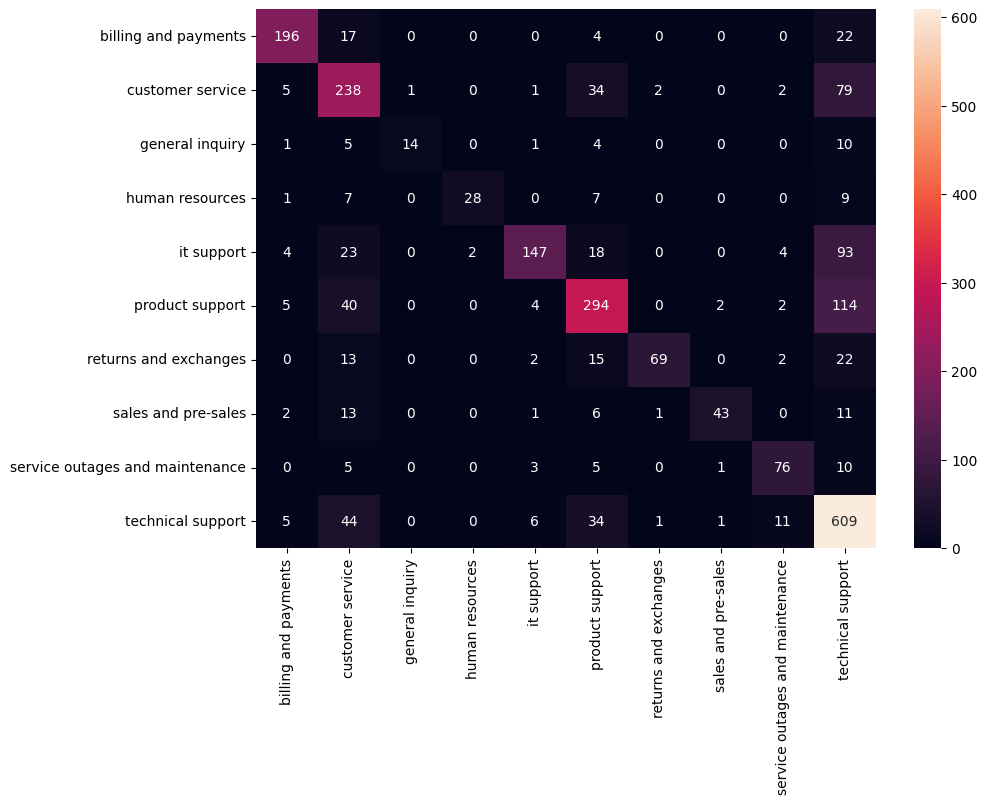

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=model.classes_, yticklabels=model.classes_,)

When inspecting the precison, recall and f1-score as well as support for each class (for either test and validation, since they are close to eah other), we see the mentioned imbalance in class distribution in the test data (Said inbalance will be kept, since in a real world scenario, the distribution would be uneven as well). Were the class 'technical support' perfomed the best on the confusion matrix for example, we now observe a relatively low precision and average f1-score.

For this scenario, we want to have a high f1-score so that tickets are not constantly routed to the wrong department. The overall f1-score is already decent but for several singular classes (e.g. 'general inquiry') its still rather low, meaning the model will perform espacially poor in these cases. As such, in the next step we will perfom some model tuning, to improve the models perfomance.

In [8]:
print("Test Results:")
print(classification_report(y_test, y_pred))

y_val_pred = model.predict(X_validation_vec)
print("Validation Results:")
print(classification_report(y_validation, y_val_pred))

Test Results:
                                 precision    recall  f1-score   support

           billing and payments       0.89      0.82      0.86       239
               customer service       0.59      0.66      0.62       362
                general inquiry       0.93      0.40      0.56        35
                human resources       0.93      0.54      0.68        52
                     it support       0.89      0.51      0.64       291
                product support       0.70      0.64      0.67       461
          returns and exchanges       0.95      0.56      0.70       123
            sales and pre-sales       0.91      0.56      0.69        77
service outages and maintenance       0.78      0.76      0.77       100
              technical support       0.62      0.86      0.72       711

                       accuracy                           0.70      2451
                      macro avg       0.82      0.63      0.69      2451
                   weighted avg    

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


#### Tune the model

To try and improve the models performance, we will use GridSearchCV. With this, we can do an "exhaustive search over specified parameter values for an estimator"[^1]. We train the resulting model again.

[^1]: [GridSearchCV Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

In [13]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'max_features': ['sqrt', 'log2'],
}

tree = RandomForestClassifier(verbose= 1, random_state=42, n_jobs=-1) # Initialize a model
model = GridSearchCV(tree,parameters) # Use grid serach, to find the best performing model with the given parameters
model.fit(X_resampled, y_resampled) # Train the model

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0

GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=42,
                                              verbose=1),
             param_grid={'max_depth': [10, 20, 30, None],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 200, 300]})

The new model shows some minor improvements but overall performs rather similar to the original model (other resampling methods, paramters and estimators were tested and the results are similar).  While there is more that can be done with machine learning methods, we will instead explore the capabilities of deep learning methods next.

In [15]:
y_pred = model.predict(X_test_vec)
print("Test Results:")
print(classification_report(y_test, y_pred))

y_val_pred = model.predict(X_validation_vec)
print("Validation Results:")
print(classification_report(y_validation, y_val_pred))

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.2s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


Test Results:
                                 precision    recall  f1-score   support

           billing and payments       0.93      0.83      0.88       239
               customer service       0.63      0.71      0.67       362
                general inquiry       1.00      0.40      0.57        35
                human resources       0.93      0.50      0.65        52
                     it support       0.91      0.53      0.67       291
                product support       0.76      0.69      0.72       461
          returns and exchanges       0.96      0.59      0.73       123
            sales and pre-sales       0.96      0.61      0.75        77
service outages and maintenance       0.92      0.73      0.82       100
              technical support       0.64      0.89      0.74       711

                       accuracy                           0.73      2451
                      macro avg       0.86      0.65      0.72      2451
                   weighted avg    

[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s


Validation Results:
                                 precision    recall  f1-score   support

           billing and payments       0.91      0.87      0.89       271
               customer service       0.65      0.71      0.68       410
                general inquiry       1.00      0.65      0.79        40
                human resources       0.97      0.58      0.72        59
                     it support       0.91      0.54      0.68       330
                product support       0.74      0.67      0.71       523
          returns and exchanges       0.96      0.51      0.67       140
            sales and pre-sales       0.98      0.53      0.69        87
service outages and maintenance       0.94      0.78      0.85       113
              technical support       0.64      0.89      0.74       805

                       accuracy                           0.73      2778
                      macro avg       0.87      0.67      0.74      2778
                   weighted a

[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.2s finished
